In [1]:
!pip install yfinance pandas numpy tensorflow scikit-learn matplotlib plotly

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [3]:
# Define stocks to train on
STOCKS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'AMD', 'NFLX', 'JPM']

# Training parameters
LOOKBACK = 60        # Days of historical data to look back
HORIZON = 7          # Days to predict forward
EPOCHS = 100
BATCH_SIZE = 32
TEST_SPLIT = 0.2     # 20% of data for testing

# Data parameters
START_DATE = '2018-01-01'  # 5+ years for better training
END_DATE = '2026-03-22'

# Create output directory
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/forecasts', exist_ok=True)

print(f"Will train on {len(STOCKS)} stocks: {STOCKS}")


Will train on 10 stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'AMD', 'NFLX', 'JPM']


In [4]:
# ## 4. Data Fetching Function

# %%
def fetch_stock_data(ticker, start, end):
    """Fetch historical stock data from Yahoo Finance"""
    print(f"Fetching {ticker} data...")
    df = yf.download(ticker, start=start, end=end, progress=False)

    if df.empty:
        print(f"  ❌ No data for {ticker}")
        return None

    # Use adjusted close (accounts for splits/dividends)
    prices = df['Adj Close'].values.reshape(-1, 1)

    # Calculate daily returns (for additional feature)
    returns = df['Adj Close'].pct_change().fillna(0).values.reshape(-1, 1)

    print(f"  ✅ Fetched {len(prices)} days of data")
    return prices, returns, df


In [8]:
# ## 5. Create Sequences for LSTM

# %%
def create_sequences(data, lookback, horizon):
    """Create X (lookback days) and y (next horizon days) sequences"""
    X, y = [], []
    for i in range(len(data) - lookback - horizon):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+horizon])
    return np.array(X), np.array(y)

# %% [markdown]
# ## 6. LSTM Model Builder

# %%
def build_lstm_model(lookback, horizon, n_features=1):
    """Build and compile LSTM model"""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


In [9]:
# ## 6. LSTM Model Builder

# %%
def build_lstm_model(lookback, horizon, n_features=1):
    """Build and compile LSTM model"""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


In [11]:
# %% [markdown]
## 7. Training Loop for All Stocks (FIXED)

# %%
# Store all results
training_results = {}
all_forecasts = {}

for ticker in STOCKS:
    print(f"\n{'='*50}")
    print(f"Training model for {ticker}")
    print('='*50)

    # Fetch data
    print(f"Fetching {ticker} data...")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)

    if df.empty:
        print(f"  ❌ No data for {ticker}")
        continue

    # FIX: Use 'Close' instead of 'Adj Close' to avoid MultiIndex issues
    if 'Close' in df.columns:
        prices = df['Close'].values.reshape(-1, 1)
    elif ('Close', ticker) in df.columns:
        prices = df[('Close', ticker)].values.reshape(-1, 1)
    else:
        # Fallback: use the first column
        first_col = df.columns[0]
        prices = df[first_col].values.reshape(-1, 1)

    print(f"  ✅ Fetched {len(prices)} days of data")

    # Check if we have enough data
    if len(prices) < LOOKBACK + HORIZON + 10:
        print(f"  ❌ Insufficient data for {ticker} (need {LOOKBACK + HORIZON + 10}, got {len(prices)})")
        continue

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(prices)

    # Create sequences
    X, y = [], []
    for i in range(len(scaled_data) - LOOKBACK - HORIZON):
        X.append(scaled_data[i:i+LOOKBACK])
        y.append(scaled_data[i+LOOKBACK:i+LOOKBACK+HORIZON])

    X = np.array(X)
    y = np.array(y)

    if len(X) == 0:
        print(f"  ❌ Not enough sequences for {ticker}")
        continue

    # Train/test split (chronological)
    split_idx = int(len(X) * (1 - TEST_SPLIT))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"  Training samples: {len(X_train)}, Test samples: {len(X_test)}")

    # Build and train model
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate
    train_loss = model.evaluate(X_train, y_train, verbose=0)
    test_loss = model.evaluate(X_test, y_test, verbose=0)

    print(f"  ✅ Training complete - Train Loss: {train_loss[0]:.6f}, Test Loss: {test_loss[0]:.6f}")

    # Generate forecast for next 7 days from latest data
    last_sequence = scaled_data[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    forecast_scaled = model.predict(last_sequence, verbose=0)
    forecast = scaler.inverse_transform(forecast_scaled).flatten()

    # Get actual last price
    last_price = prices[-1][0]

    # Store everything
    training_results[ticker] = {
        'model': model,
        'scaler': scaler,
        'train_loss': train_loss[0],
        'test_loss': test_loss[0],
        'test_mae': train_loss[1],
        'history': history.history
    }

    all_forecasts[ticker] = {
        'forecast': forecast.tolist(),
        'last_price': float(last_price),
        'forecast_dates': [(datetime.now() + timedelta(days=i+1)).strftime('%Y-%m-%d') for i in range(HORIZON)]
    }

    # Plot forecast
    plt.figure(figsize=(10, 4))
    plt.plot(range(HORIZON), forecast, marker='o', linewidth=2, color='green')
    plt.axhline(y=last_price, color='gray', linestyle='--', alpha=0.5, label='Current Price')
    plt.title(f'{ticker} - 7 Day Forecast')
    plt.xlabel('Days Ahead')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'/content/forecasts/{ticker}_forecast.png')
    plt.close()

    print(f"  📊 Forecast: ${last_price:.2f} → ${forecast[0]:.2f} → ${forecast[-1]:.2f} (7-day change: {((forecast[-1]-last_price)/last_price*100):+.1f}%)")

print(f"\n{'='*50}")
print(f"✅ Training completed for {len(training_results)} stocks")
print('='*50)


Training model for AAPL
Fetching AAPL data...
  ✅ Fetched 2065 days of data
  Training samples: 1598, Test samples: 400
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - loss: 0.0253 - mae: 0.0969 - val_loss: 0.0112 - val_mae: 0.0945
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0032 - mae: 0.0399 - val_loss: 0.0078 - val_mae: 0.0788
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0029 - mae: 0.0382 - val_loss: 0.0108 - val_mae: 0.0953
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 0.0026 - mae: 0.0351 - val_loss: 0.0033 - val_mae: 0.0477
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - loss: 0.0020 - mae: 0.0315 - val_loss: 0.0080 - val_mae: 0.0810
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - loss: 0.0021 - mae: 0.0322 - val_loss: 0.0029 - val_mae: 0.0437
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - loss: 0.0016 - mae: 0.0282 - val_loss: 0.0037 - val_mae: 0.0514
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 

  📊 Forecast: $593.66 → $617.40 → $621.73 (7-day change: +4.7%)

Training model for NVDA
Fetching NVDA data...
  ✅ Fetched 2065 days of data
  Training samples: 1598, Test samples: 400
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - loss: 0.0043 - mae: 0.0333 - val_loss: 0.0096 - val_mae: 0.0839
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 7.3554e-04 - mae: 0.0150 - val_loss: 0.0042 - val_mae: 0.0525
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - loss: 7.3192e-04 - mae: 0.0157 - val_loss: 0.0118 - val_mae: 0.0971
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 5.6260e-04 - mae: 0.0137 - val_loss: 0.0093 - val_mae: 0.0863
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - loss: 6.1372e-04 - mae: 0.0145 - val_loss: 0.0092 - val_mae: 0.0843
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 4.4808e-04 - mae: 0.0118 - val_loss: 0.0035 - val_mae: 0.0478
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 5.2153e-04 - mae: 0

  📊 Forecast: $172.70 → $177.09 → $170.60 (7-day change: -1.2%)

Training model for TSLA
Fetching TSLA data...
  ✅ Fetched 2065 days of data
  Training samples: 1598, Test samples: 400
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - loss: 0.0266 - mae: 0.0992 - val_loss: 0.0072 - val_mae: 0.0657
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 0.0042 - mae: 0.0442 - val_loss: 0.0109 - val_mae: 0.0862
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0035 - mae: 0.0401 - val_loss: 0.0098 - val_mae: 0.0815
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - loss: 0.0033 - mae: 0.0384 - val_loss: 0.0067 - val_mae: 0.0654
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0032 - mae: 0.0381 - val_loss: 0.0139 - val_mae: 0.1004
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0026 - mae: 0.0345 - val_loss: 0.0061 - val_mae: 0.0623
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0024 - mae: 0.0331 - val_loss: 0.005

In [12]:
## 8. Save Models and Scalers

# %%
# Save each model and scaler individually
for ticker, result in training_results.items():
    # Save model
    model_path = f'/content/models/{ticker}_lstm.h5'
    result['model'].save(model_path)
    print(f"✅ Saved model: {model_path}")

    # Save scaler
    scaler_path = f'/content/models/{ticker}_scaler.pkl'
    with open(scaler_path, 'wb') as f:
        pickle.dump(result['scaler'], f)
    print(f"✅ Saved scaler: {scaler_path}")

# Also save combined metadata
metadata = {
    'tickers': list(training_results.keys()),
    'lookback': LOOKBACK,
    'horizon': HORIZON,
    'training_date': datetime.now().isoformat(),
    'performance': {
        ticker: {
            'test_loss': float(result['test_loss']),
            'test_mae': float(result['test_mae'])
        }
        for ticker, result in training_results.items()
    }
}

with open('/content/models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

with open('/content/models/metadata.json', 'w') as f:
    import json
    json.dump(metadata, f, indent=2)

print("\n✅ All models and metadata saved!")

✅ Saved model: /content/models/AAPL_lstm.h5
✅ Saved scaler: /content/models/AAPL_scaler.pkl
✅ Saved model: /content/models/MSFT_lstm.h5
✅ Saved scaler: /content/models/MSFT_scaler.pkl
✅ Saved model: /content/models/GOOGL_lstm.h5
✅ Saved scaler: /content/models/GOOGL_scaler.pkl
✅ Saved model: /content/models/AMZN_lstm.h5
✅ Saved scaler: /content/models/AMZN_scaler.pkl


✅ Saved model: /content/models/META_lstm.h5
✅ Saved scaler: /content/models/META_scaler.pkl
✅ Saved model: /content/models/NVDA_lstm.h5
✅ Saved scaler: /content/models/NVDA_scaler.pkl


✅ Saved model: /content/models/TSLA_lstm.h5
✅ Saved scaler: /content/models/TSLA_scaler.pkl
✅ Saved model: /content/models/AMD_lstm.h5
✅ Saved scaler: /content/models/AMD_scaler.pkl
✅ Saved model: /content/models/NFLX_lstm.h5
✅ Saved scaler: /content/models/NFLX_scaler.pkl
✅ Saved model: /content/models/JPM_lstm.h5
✅ Saved scaler: /content/models/JPM_scaler.pkl

✅ All models and metadata saved!


In [13]:
# %% [markdown]
## 9. Export Forecasts

# %%
# Save all forecasts
forecasts_data = []
for ticker, forecast_data in all_forecasts.items():
    forecasts_data.append({
        'ticker': ticker,
        'last_price': forecast_data['last_price'],
        'forecast_day1': forecast_data['forecast'][0],
        'forecast_day2': forecast_data['forecast'][1],
        'forecast_day3': forecast_data['forecast'][2],
        'forecast_day4': forecast_data['forecast'][3],
        'forecast_day5': forecast_data['forecast'][4],
        'forecast_day6': forecast_data['forecast'][5],
        'forecast_day7': forecast_data['forecast'][6],
        'expected_change_pct': ((forecast_data['forecast'][-1] - forecast_data['last_price']) / forecast_data['last_price']) * 100
    })

forecasts_df = pd.DataFrame(forecasts_data)
forecasts_df.to_csv('/content/forecasts/latest_forecasts.csv', index=False)

print("\n📊 Latest Forecasts:")
print(forecasts_df[['ticker', 'last_price', 'forecast_day7', 'expected_change_pct']].to_string(index=False))


📊 Latest Forecasts:
ticker  last_price  forecast_day7  expected_change_pct
  AAPL  247.990005     246.855728            -0.457388
  MSFT  381.869995     392.466125             2.774800
 GOOGL  301.000000     306.652496             1.877906
  AMZN  205.369995     204.321701            -0.510442
  META  593.659973     621.727356             4.727855
  NVDA  172.699997     170.595215            -1.218751
  TSLA  367.959991     372.201874             1.152811
   AMD  201.330002     195.807373            -2.743073
  NFLX   91.820000      91.256973            -0.613185
   JPM  286.559998     290.608948             1.412950


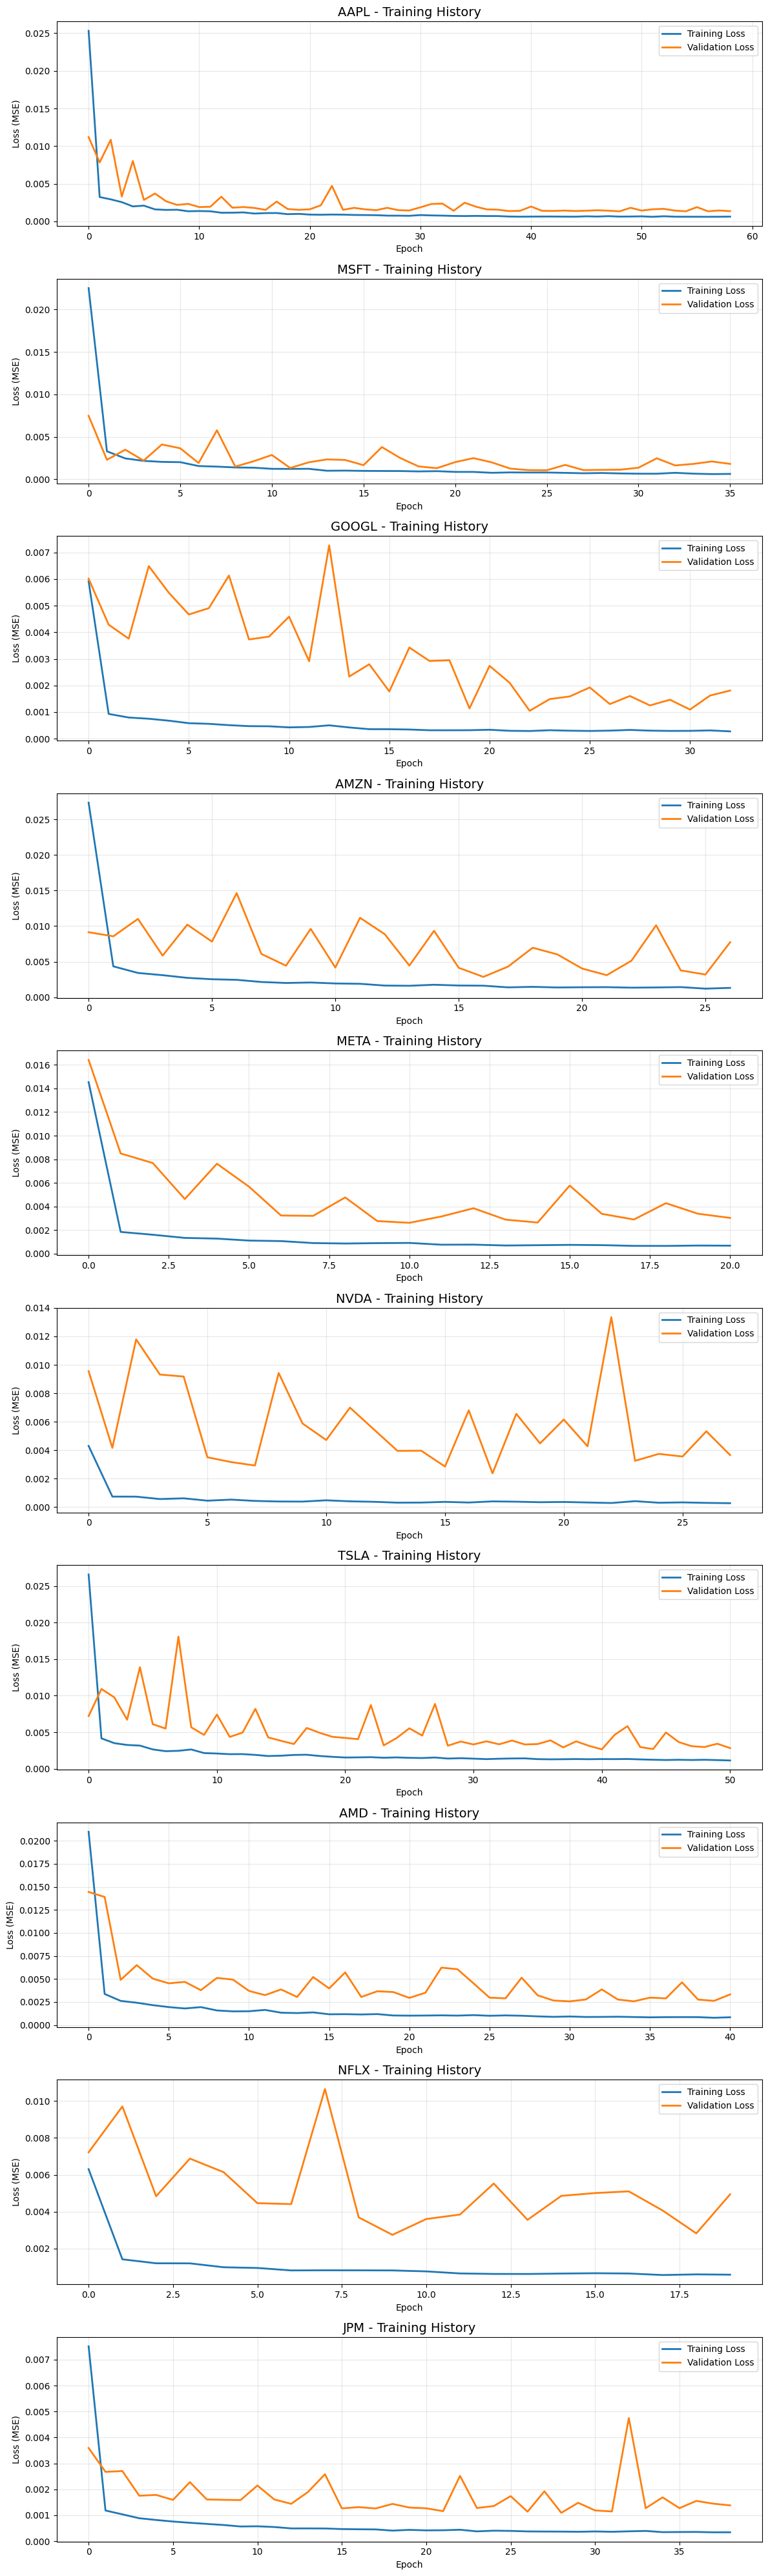


✅ Training history plot saved!


In [14]:
# %% [markdown]
## 11. Plot Training History for All Stocks

# %%
# Plot loss curves for all trained stocks
num_stocks = len(training_results)
if num_stocks > 0:
    fig, axes = plt.subplots(num_stocks, 1, figsize=(12, 4*num_stocks))
    if num_stocks == 1:
        axes = [axes]

    for idx, (ticker, result) in enumerate(training_results.items()):
        ax = axes[idx]
        history = result['history']
        ax.plot(history['loss'], label='Training Loss', linewidth=2)
        ax.plot(history['val_loss'], label='Validation Loss', linewidth=2)
        ax.set_title(f'{ticker} - Training History', fontsize=14)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (MSE)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/forecasts/training_history.png', dpi=100)
    plt.show()

    print("\n✅ Training history plot saved!")
else:
    print("\n⚠️ No stocks were successfully trained to plot history.")

In [16]:
# %% [markdown]
## 12. Create Downloadable Archive

# %%
import zipfile
import os
from google.colab import files as colab_files

# Create zip archive
zip_path = '/content/videntis_models.zip'

# Clean up old zip if exists
if os.path.exists(zip_path):
    os.remove(zip_path)

# Create the zip file
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add model files
    for root, dirs, files in os.walk('/content/models'):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = f"models/{file}"
            zipf.write(file_path, arcname)

    # Add forecast files
    for root, dirs, files in os.walk('/content/forecasts'):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = f"forecasts/{file}"
            zipf.write(file_path, arcname)

# Check zip size
zip_size = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\n✅ Created archive: {zip_path} ({zip_size:.2f} MB)")

# Download the archive
colab_files.download(zip_path)

print("\n✅ All done! Download the zip file and extract to your backend.")
print("\n📁 Folder structure after extraction:")
print("videntis_models/")
print("├── models/")
print("│   ├── AAPL_lstm.h5")
print("│   ├── AAPL_scaler.pkl")
print("│   ├── MSFT_lstm.h5")
print("│   ├── MSFT_scaler.pkl")
print("│   ├── metadata.json")
print("│   └── metadata.pkl")
print("└── forecasts/")
print("    ├── latest_forecasts.csv")
print("    ├── AAPL_forecast.png")
print("    ├── MSFT_forecast.png")
print("    └── training_history.png")

# Optional: Show sample of saved files
print("\n📂 Saved files in /content/models/:")
!ls -lh /content/models/

print("\n📂 Saved files in /content/forecasts/:")
!ls -lh /content/forecasts/


✅ Created archive: /content/videntis_models.zip (13.51 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done! Download the zip file and extract to your backend.

📁 Folder structure after extraction:
videntis_models/
├── models/
│   ├── AAPL_lstm.h5
│   ├── AAPL_scaler.pkl
│   ├── MSFT_lstm.h5
│   ├── MSFT_scaler.pkl
│   ├── metadata.json
│   └── metadata.pkl
└── forecasts/
    ├── latest_forecasts.csv
    ├── AAPL_forecast.png
    ├── MSFT_forecast.png
    └── training_history.png

📂 Saved files in /content/models/:
total 15M
-rw-r--r-- 1 root root 1.4M Mar 22 06:25 AAPL_lstm.h5
-rw-r--r-- 1 root root  522 Mar 22 06:25 AAPL_scaler.pkl
-rw-r--r-- 1 root root 1.4M Mar 22 06:25 AMD_lstm.h5
-rw-r--r-- 1 root root  522 Mar 22 06:25 AMD_scaler.pkl
-rw-r--r-- 1 root root 1.4M Mar 22 06:25 AMZN_lstm.h5
-rw-r--r-- 1 root root  522 Mar 22 06:25 AMZN_scaler.pkl
-rw-r--r-- 1 root root 1.4M Mar 22 06:25 GOOGL_lstm.h5
-rw-r--r-- 1 root root  522 Mar 22 06:25 GOOGL_scaler.pkl
-rw-r--r-- 1 root root 1.4M Mar 22 06:25 JPM_lstm.h5
-rw-r--r-- 1 root root  522 Mar 22 06:25 JPM_scaler.pkl
-rw-r--r-- 1